In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os

from plotting_helpers import load_loss,get_resonstructions

/home/kong/anaconda3/lib/python3.8/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: '/home/kong/anaconda3/lib/python3.8/site-packages/torchvision/image.so: undefined symbol: _ZNK3c107SymBool10guard_boolEPKcl'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(


In [22]:
plt.rcParams['font.size'] = 16
plt.rcParams['lines.linewidth'] = 2
plt.rcParams['axes.linewidth'] = 2

In [23]:
plot_path = '/home/kong/cifar_plots/figs/test/'
if not os.path.exists(plot_path):
    os.makedirs(plot_path)

In [37]:
run_id = '2025-03-07_13:13:33'
reps = 5
n_epochs=60
size_ls = [  6,   6,   6,   6,   6,   6,    # 6
					10,  10,  10,  10,  10,  10,    # 6
					16,  16,  16,  16,  16,  16,    # 6
					28,  28,  28,  28,  28,  28,    # 6
					48,  48,  48,  48,  48,  48,  48,  48, 48, # 9
					90,  90,  90,  90,  90,  90,  90,  90,  90,  90, #10
					128, 128, 128, 128, 128, 128, 128, 128, 128, 128,
					128, 128, 128, 128, 128, 128, 128 # 17
					]
model_types = ['sae','dae']

In [25]:
all_loss = load_loss(run_id,reps)

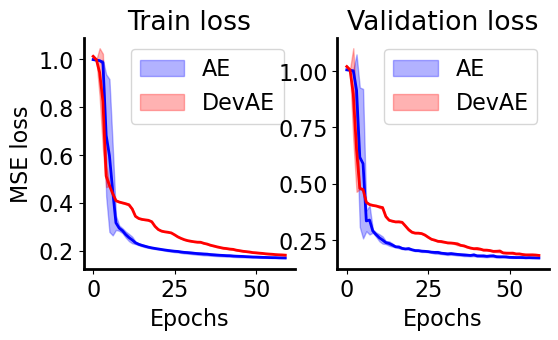

In [39]:
fig = plt.figure(figsize=(6,3))
plt.subplot(1,2,1)
y = np.mean(all_loss['sae']['train'],axis=0)
std =  np.std(all_loss['sae']['train'],axis=0)
plt.plot(y,c='b')
plt.fill_between(np.arange(len(y)),y+std,y-std,alpha=0.3,color='b',label='AE')
y = np.mean(all_loss['dae']['train'],axis=0)
std =  np.std(all_loss['dae']['train'],axis=0)
plt.plot(y,c='r')
plt.fill_between(np.arange(len(y)),y+std,y-std, alpha=0.3,color='r',label='DevAE')
plt.legend()
plt.title('Train loss')
plt.xlabel('Epochs')
plt.ylabel('MSE loss')
plt.gca().spines[['right', 'top']].set_visible(False)

plt.subplot(1,2,2)
y = np.mean(all_loss['sae']['validation'],axis=0)
std =  np.std(all_loss['sae']['validation'],axis=0)
plt.plot(y,c='b')
plt.fill_between(np.arange(len(y)),y+std,y-std,alpha=0.3,color='b', label='AE')
y = np.mean(all_loss['dae']['validation'],axis=0)
std =  np.std(all_loss['dae']['validation'],axis=0)
plt.plot(y,c='r')
plt.fill_between(np.arange(len(y)),y+std,y-std,alpha=0.3,color='r', label='DevAE')
plt.title('Validation loss')
plt.legend()
plt.xlabel('Epochs')
# plt.ylabel('MSE loss')
plt.gca().spines[['right', 'top']].set_visible(False)
plt.savefig(plot_path + 'loss.png',bbox_inches='tight')

In [38]:
recon = get_resonstructions(run_id,n_epochs,size_ls,rep=0)

Files already downloaded and verified


/home/kong/anaconda3/lib/python3.8/site-packages/torch/utils/data/dataloader.py:563: UserWarning: This DataLoader will create 6 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(


128


/home/kong/developing-autoencoders/solver.py:639: UserWarning: volatile was removed and now has no effect. Use `with torch.no_grad():` instead.
  data = Variable(data, volatile=True)


====> Test set loss: 0.1794
128
====> Test set loss: 0.1690


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping i

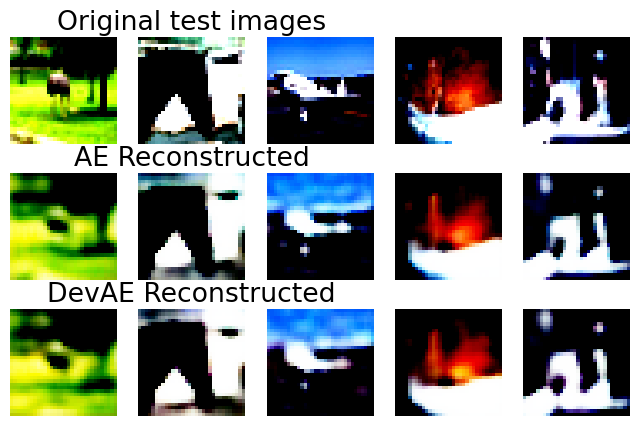

In [51]:
fig = plt.figure(figsize=(8,5))
for i in range(5,10):
    plt.subplot(3,5,i-4)
    plt.imshow(np.transpose(recon['original'][i].numpy(),(1,2,0)))
    if i == 6:
        plt.title('Original test images')
    plt.axis('off')

    plt.subplot(3,5,i+1)
    plt.imshow(np.transpose(recon['sae'][i].detach().numpy(),(1,2,0)))
    if i == 6:
        plt.title('AE Reconstructed')
    plt.axis('off')

for i in range(5,10):
    plt.subplot(3,5,i+6)
    plt.imshow(np.transpose(recon['dae'][i].detach().numpy(),(1,2,0)))
    if i == 6:
        plt.title('DevAE Reconstructed')
    plt.axis('off')
plt.savefig(plot_path + 'reconstructions.png',bbox_inches='tight')